## **1. Setup & Library Imports**

In [3]:
import os
import torch
import random
import numpy as np
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
device = torch.device("cpu")

## **2. Dataset Preparation**

In [4]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset  = datasets.MNIST(root='./data', train=False, transform=transform, download=True)

batch_size = 1024
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

## **3. VAE**

In [5]:
def loss_function(x, x_recon, mu, logvar):
    BCE = nn.functional.binary_cross_entropy(x_recon, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD

In [6]:
class VAE(nn.Module):
    def __init__(self, latent_dim):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim

        self.encoder = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
        )

        self.fc_mu = nn.Linear(256, latent_dim)
        self.fc_logvar = nn.Linear(256, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 28*28),
            nn.Sigmoid()  # Suitable for pixel values in [0,1]
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std  # Reparameterization trick

    def forward(self, x):
        x = x.view(x.size(0), -1)
        h = self.encoder(x)

        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)

        z = self.reparameterize(mu, logvar)

        x_recon = self.decoder(z)
        x_recon = x_recon.view(x.size(0), 1, 28, 28)
        return x_recon, mu, logvar, z


latent_dim = 2
model = VAE(latent_dim=latent_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=3e-3)

## **4. Model Training**

**M09VAE03**

Câu hỏi: Latent Space tại Epoch 9 là?

A. **A**

B. **B**

C. **C**

D. **D**

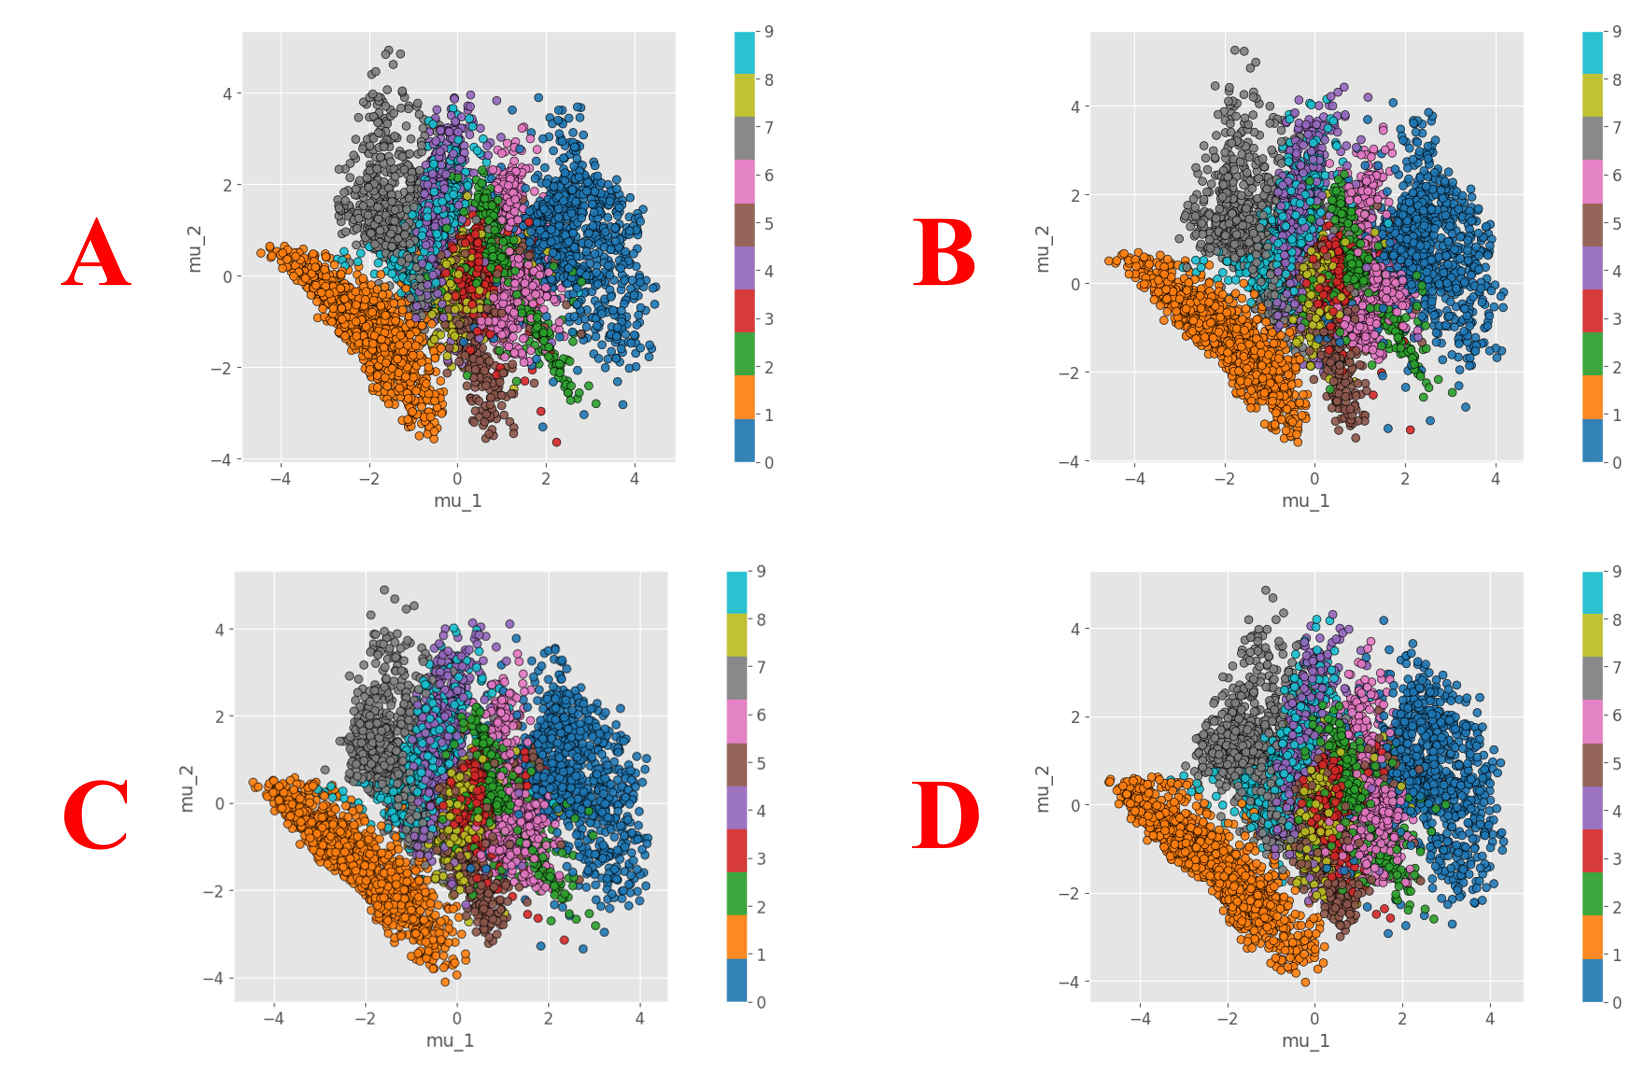

Epoch 1/10, Loss: 223.4278


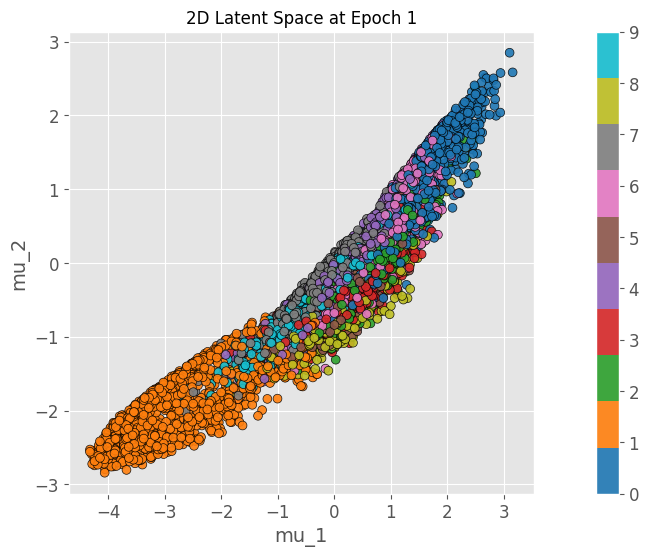

Epoch 2/10, Loss: 177.5917


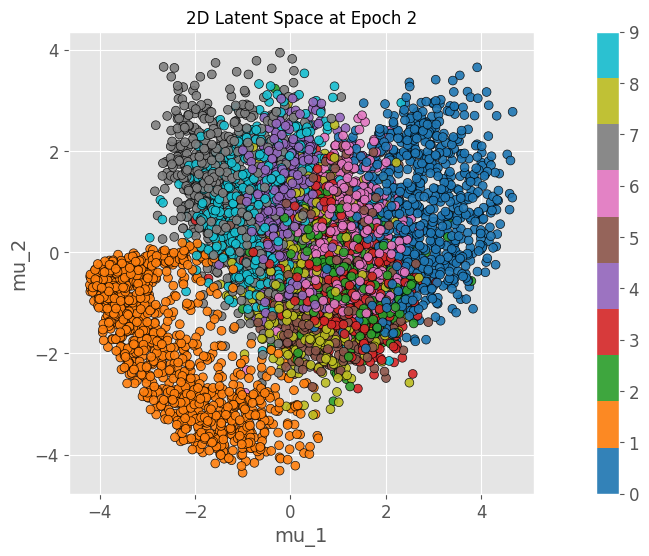

Epoch 3/10, Loss: 167.2781


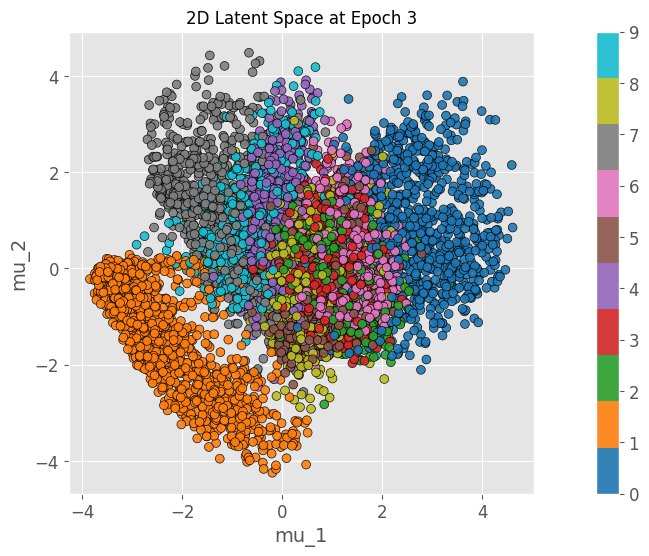

Epoch 4/10, Loss: 163.1459


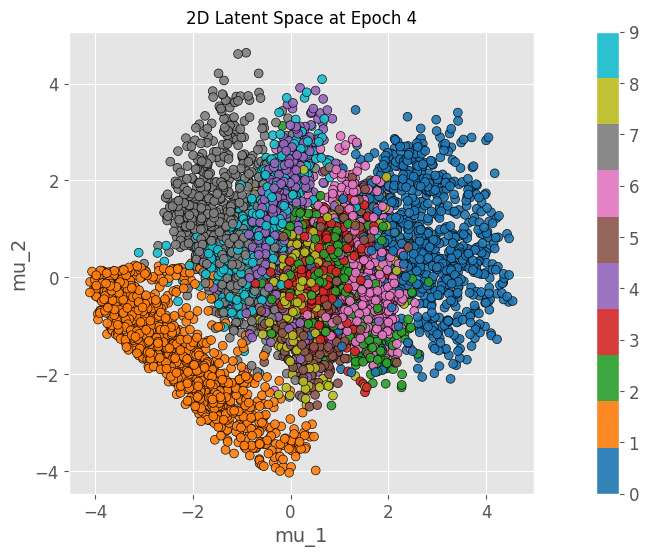

Epoch 5/10, Loss: 159.4927


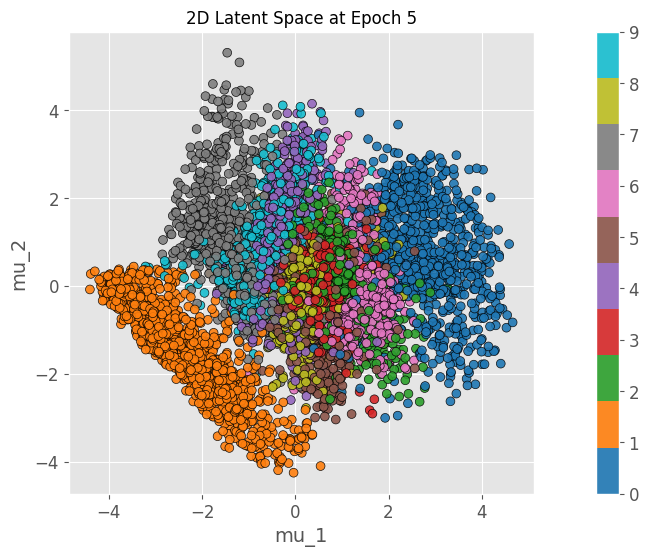

Epoch 6/10, Loss: 156.8140


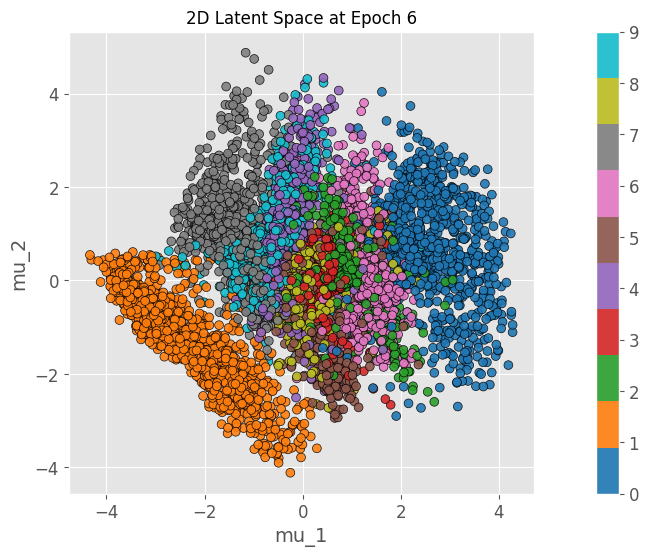

Epoch 7/10, Loss: 154.5965


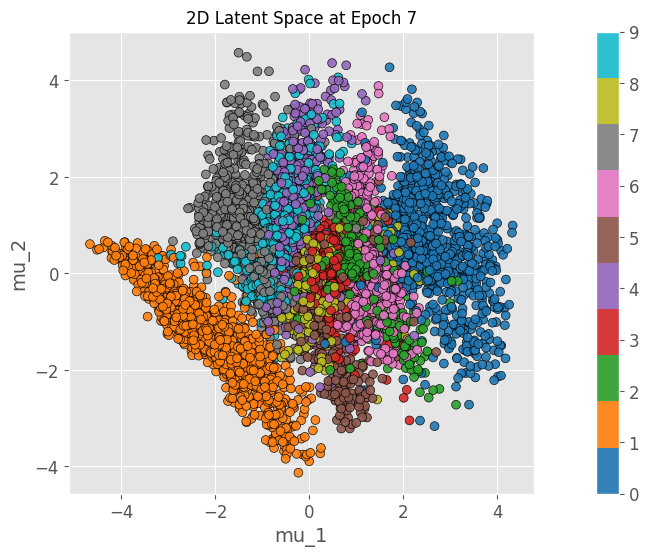

Epoch 8/10, Loss: 152.9963


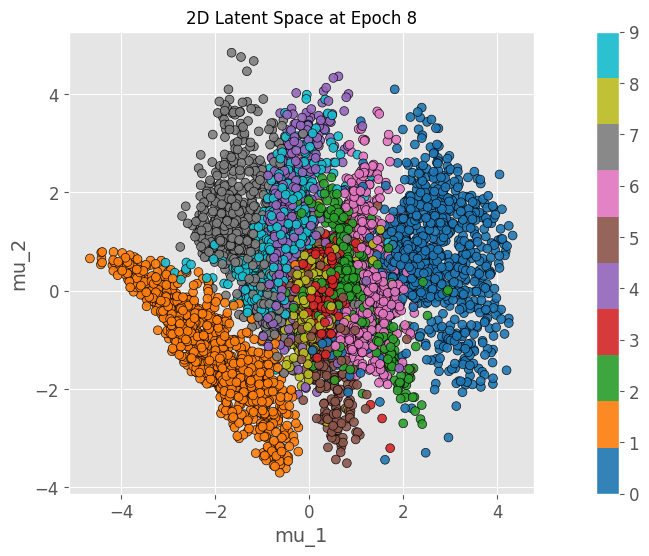

Epoch 9/10, Loss: 151.7138


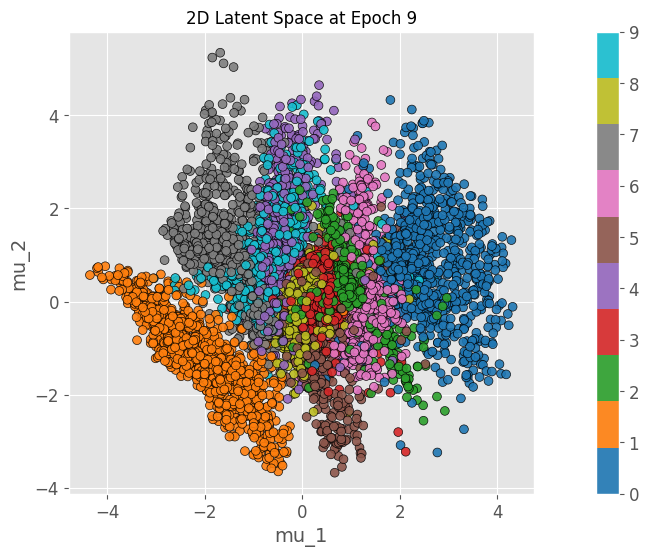

Epoch 10/10, Loss: 150.5123


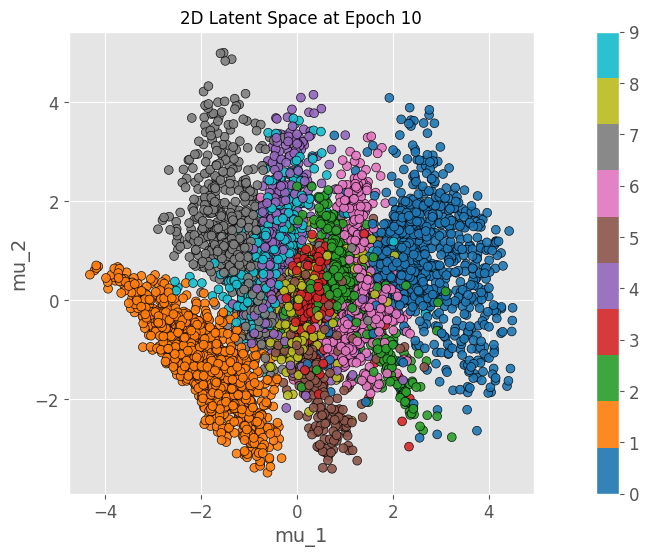

In [7]:
plt.style.use('ggplot')
plt.rcParams.update({
    'figure.figsize': (8, 6),
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12
})

num_epochs = 10
loss_history = []
latent_history = []

for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)                     # Load data to device
        optimizer.zero_grad()                      # Zero gradients
        x_recon, mu, logvar, z = model(data)       # Forward pass
        loss = loss_function(data, x_recon, mu, logvar)  # Compute loss
        loss.backward()                            # Backward pass

        train_loss += loss.item()
        optimizer.step()

    avg_loss = train_loss / len(train_loader.dataset)
    loss_history.append(avg_loss)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")

    # plot latent space
    model.eval()
    all_mu = []
    all_labels = []
    with torch.no_grad():
        for data, labels in test_loader:
            data = data.to(device)
            _, mu, logvar, z = model(data)
            all_mu.append(mu.cpu().numpy())
            all_labels.append(labels.numpy())

    all_mu = np.concatenate(all_mu, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)
    latent_history.append((all_mu, all_labels))

    plt.figure(figsize=(8,6))
    sc = plt.scatter(all_mu[:, 0], all_mu[:, 1],
                     c=all_labels, cmap='tab10', s=40, alpha=0.9, edgecolors='k')
    plt.title(f"2D Latent Space at Epoch {epoch+1}", fontsize=12)
    plt.xlabel("mu_1", fontsize=14)
    plt.ylabel("mu_2", fontsize=14)
    cbar = plt.colorbar(sc, pad=0.1, ticks=range(10))
    cbar.ax.set_yticklabels([str(i) for i in range(10)])
    plt.show()


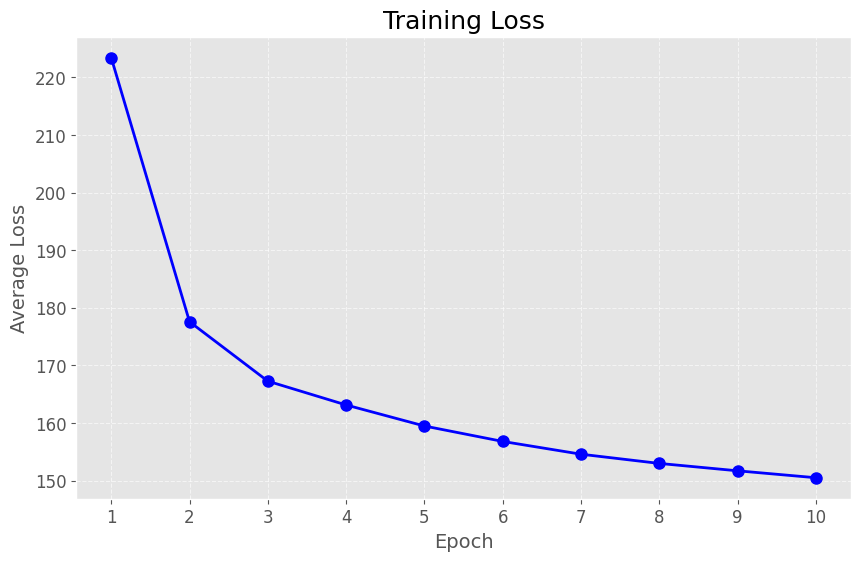

In [8]:
plt.figure(figsize=(10,6))
plt.plot(range(1, num_epochs+1), loss_history, marker='o', linestyle='-', color='b', linewidth=2, markersize=8)
plt.title("Training Loss", fontsize=18)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Average Loss", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(range(1, num_epochs+1))
plt.show()

## **5. Number Reconstruction**

M09VAE04:

Câu hỏi: Số mấy không có trong hình ảnh được tái tạo lại (reconstructed) ?

A. số 0

B. số 1

C. số 5

D. số 9

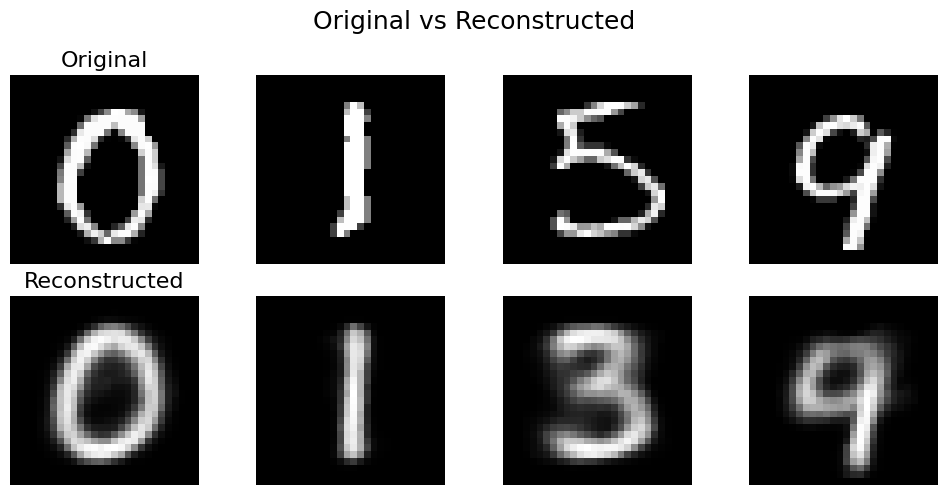

In [9]:
model.eval()
with torch.no_grad():
    data, _ = next(iter(test_loader))
    data = data.to(device)
    recon, _, _, _ = model(data)

n = 4
fig, axes = plt.subplots(2, n, figsize=(10, 5))
for i in range(n):
    axes[0, i].imshow(data[i+13].cpu().squeeze(), cmap='gray')
    axes[0, i].axis("off")
    if i == 0:
        axes[0, i].set_title("Original", fontsize=16)

    axes[1, i].imshow(recon[i+13].cpu().squeeze(), cmap='gray')
    axes[1, i].axis("off")
    if i == 0:
        axes[1, i].set_title("Reconstructed", fontsize=16)

plt.suptitle("Original vs Reconstructed", fontsize=18)
plt.tight_layout()
plt.show()